Loading Block B (SMOTE) objects...
  SMOTE training set: 35,898 rows
  Test set          : 6,519 rows
  Optimal threshold : 0.377

C1: Training Logistic Regression (baseline)...
  ✅ Logistic Regression trained  |  Test AUC: 0.8794

C2: Training Decision Tree with GridSearchCV...
  Best params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 20}
  ✅ Decision Tree trained  |  Test AUC: 0.8939

C3: Training Random Forest with GridSearchCV...
  Best params: {'max_depth': None, 'max_features': 'log2', 'n_estimators': 200}
  ✅ Random Forest trained  |  Test AUC: 0.8971

C4: Training XGBoost with GridSearchCV...
  Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
  ✅ XGBoost trained  |  Test AUC: 0.9079

C5: AUC summary (test set)
  XGBoost                   AUC=0.9079  ███████████████████████████ ← BEST
  Random Forest             AUC=0.8971  ██████████████████████████
  Decision Tree             AUC=0.8939  ██████████████████████████
  

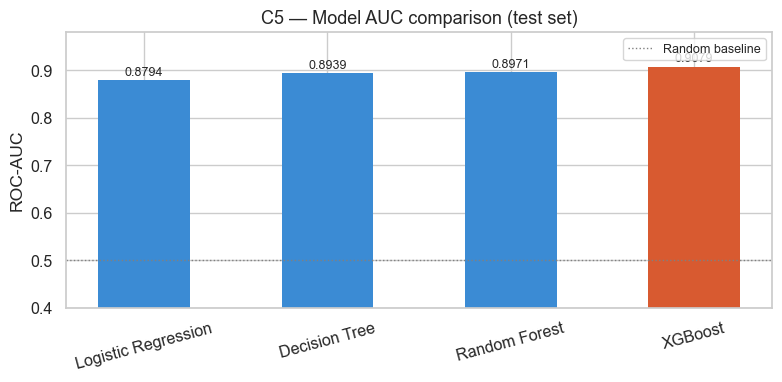

  Saved → ./outputs/phase4/block_c/C5_auc_comparison.png

C6: Saving trained models...
  Saved → ./outputs/phase4/block_c/block_c_objects.pkl

BLOCK C COMPLETE — Model Training

  Models trained (on SMOTE-balanced data):
    1. Logistic Regression  AUC = 0.8794
    2. Decision Tree        AUC = 0.8939
    3. Random Forest        AUC = 0.8971
    4. XGBoost              AUC = 0.9079

  Best model so far : XGBoost  (AUC = 0.9079)

  Hyperparameter tuning:
    Decision Tree : GridSearchCV  (max_depth, min_samples_leaf, criterion)
    Random Forest : GridSearchCV  (n_estimators, max_depth, max_features)
    XGBoost       : GridSearchCV  (n_estimators, max_depth, learning_rate, subsample)

  All predictions made on the UNTOUCHED test set.

  Saved → ./outputs/phase4/block_c/block_c_objects.pkl

─────────────────────────────────────────────────────────
Next → Run phase4_block_d_model_comparison.py
─────────────────────────────────────────────────────────



In [1]:
"""
=============================================================
Phase 4 — Block C: Model Training
=============================================================
Goal: Train four models on the SMOTE-balanced training data
      and save them for comparison in Block D.

Models trained:
  1. Logistic Regression    — Phase 3 baseline, interpretable
  2. Decision Tree          — simple, fully interpretable tree
  3. Random Forest          — ensemble of trees, robust
  4. XGBoost                — gradient boosting, typically best

For each model:
  • Fit on SMOTE-balanced X_train_res / y_train_res
  • Predict on the ORIGINAL X_test / y_test (untouched)
  • Hyperparameter tuning for Random Forest and XGBoost
    via GridSearchCV with 5-fold cross-validation

Why compare multiple models?
  No single algorithm is always best. By comparing all four
  we can make a data-driven choice for Block E (risk scoring)
  and demonstrate ML breadth in the portfolio.
"""

import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

# ── Config ────────────────────────────────────────────────────
BLOCK_B_PATH = './outputs/phase4/block_b/'
OUTPUT_PATH  = './outputs/phase4/block_c/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

COLORS = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'coral':  '#D85A30',
    'gray':   '#888780',
    'purple': '#7F77DD',
    'amber':  '#BA7517',
}
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

# ── Load Block B objects ───────────────────────────────────────
print("Loading Block B (SMOTE) objects...")
with open(os.path.join(BLOCK_B_PATH, 'block_b_objects.pkl'), 'rb') as f:
    b = pickle.load(f)

X_train_res  = b['X_train_res']
y_train_res  = b['y_train_res']
X_test       = b['X_test']
y_test       = b['y_test']
best_thresh  = b['best_threshold']
FEATURES     = b['feature_names']
RANDOM_STATE = b['RANDOM_STATE']

print(f"  SMOTE training set: {X_train_res.shape[0]:,} rows")
print(f"  Test set          : {X_test.shape[0]:,} rows")
print(f"  Optimal threshold : {best_thresh:.3f}\n")

# Cross-validation strategy (shared by all models)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


# =============================================================
# C1: Logistic Regression (baseline)
# =============================================================
# Same model as Phase 3, now retrained on SMOTE data and with
# the richer Phase 4 feature set. Serves as the interpretable
# baseline that all other models must beat.

print("C1: Training Logistic Regression (baseline)...")

lr = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    C=1.0,              # inverse regularisation strength (default)
    solver='lbfgs',
)
lr.fit(X_train_res, y_train_res)

lr_proba = lr.predict_proba(X_test)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_proba)

print(f"  ✅ Logistic Regression trained  |  Test AUC: {lr_auc:.4f}\n")


# =============================================================
# C2: Decision Tree
# =============================================================
# A single decision tree is fully interpretable (you can print
# the tree and follow every split). It tends to overfit without
# depth control — we use GridSearchCV to find the best max_depth.

print("C2: Training Decision Tree with GridSearchCV...")

dt_param_grid = {
    'max_depth':        [3, 5, 7, 10, None],
    'min_samples_leaf': [5, 10, 20],
    'criterion':        ['gini', 'entropy'],
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    dt_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
)
dt_grid.fit(X_train_res, y_train_res)
dt_best = dt_grid.best_estimator_

dt_proba = dt_best.predict_proba(X_test)[:, 1]
dt_auc   = roc_auc_score(y_test, dt_proba)

print(f"  Best params: {dt_grid.best_params_}")
print(f"  ✅ Decision Tree trained  |  Test AUC: {dt_auc:.4f}\n")


# =============================================================
# C3: Random Forest
# =============================================================
# An ensemble of N decision trees trained on random subsets of
# features and data (bagging). Reduces the overfitting problem
# of a single tree by averaging many uncorrelated trees.
#
# Key hyperparameters:
#   n_estimators : number of trees (more = better, up to a point)
#   max_depth    : max depth of each tree (controls overfitting)
#   max_features : number of features considered at each split

print("C3: Training Random Forest with GridSearchCV...")

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [5, 10, None],
    'max_features': ['sqrt', 'log2'],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
)
rf_grid.fit(X_train_res, y_train_res)
rf_best = rf_grid.best_estimator_

rf_proba = rf_best.predict_proba(X_test)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_proba)

print(f"  Best params: {rf_grid.best_params_}")
print(f"  ✅ Random Forest trained  |  Test AUC: {rf_auc:.4f}\n")


# =============================================================
# C4: XGBoost
# =============================================================
# Gradient Boosting builds trees SEQUENTIALLY — each new tree
# corrects the errors of the previous ensemble.
#
# Key hyperparameters:
#   n_estimators  : number of boosting rounds
#   max_depth     : tree depth (shallower = less overfitting)
#   learning_rate : step size (smaller = more robust, slower)
#   subsample     : fraction of training rows per tree (regularisation)
#   colsample_bytree: fraction of features per tree

print("C4: Training XGBoost with GridSearchCV...")

xgb_param_grid = {
    'n_estimators':   [100, 200],
    'max_depth':      [3, 5, 7],
    'learning_rate':  [0.05, 0.1],
    'subsample':      [0.8, 1.0],
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False,
        n_jobs=-1,
    ),
    xgb_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
)
xgb_grid.fit(X_train_res, y_train_res)
xgb_best = xgb_grid.best_estimator_

xgb_proba = xgb_best.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_proba)

print(f"  Best params: {xgb_grid.best_params_}")
print(f"  ✅ XGBoost trained  |  Test AUC: {xgb_auc:.4f}\n")


# =============================================================
# C5: Quick AUC comparison printout
# =============================================================

model_auc = {
    'Logistic Regression': lr_auc,
    'Decision Tree':       dt_auc,
    'Random Forest':       rf_auc,
    'XGBoost':             xgb_auc,
}

print("=" * 50)
print("C5: AUC summary (test set)")
print("=" * 50)
for name, auc in sorted(model_auc.items(), key=lambda x: -x[1]):
    bar  = "█" * int(auc * 30)
    best = " ← BEST" if auc == max(model_auc.values()) else ""
    print(f"  {name:<25} AUC={auc:.4f}  {bar}{best}")
print()

# Quick bar chart
fig, ax = plt.subplots(figsize=(8, 4))
names  = list(model_auc.keys())
aucs   = list(model_auc.values())
bar_cs = [COLORS['coral'] if a == max(aucs) else COLORS['blue'] for a in aucs]

bars = ax.bar(names, aucs, color=bar_cs, edgecolor='none', width=0.5)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='Random baseline')
ax.set_ylim(0.4, min(1.0, max(aucs) * 1.08))
ax.set_title("C5 — Model AUC comparison (test set)", fontsize=13)
ax.set_ylabel("ROC-AUC")
ax.tick_params(axis='x', rotation=15)
ax.legend(fontsize=9)
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + 0.003, f"{val:.4f}",
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "C5_auc_comparison.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# C6: Save all trained models for Block D
# =============================================================

print("C6: Saving trained models...")

best_model_name = max(model_auc, key=model_auc.get)

model_objects = {
    'models': {
        'Logistic Regression': lr,
        'Decision Tree':       dt_best,
        'Random Forest':       rf_best,
        'XGBoost':             xgb_best,
    },
    'probas': {
        'Logistic Regression': lr_proba,
        'Decision Tree':       dt_proba,
        'Random Forest':       rf_proba,
        'XGBoost':             xgb_proba,
    },
    'auc_scores':    model_auc,
    'best_model_name': best_model_name,
    'X_test':        X_test,
    'y_test':        y_test,
    'X_train_res':   X_train_res,
    'y_train_res':   y_train_res,
    'best_threshold': best_thresh,
    'feature_names': FEATURES,
    'RANDOM_STATE':  RANDOM_STATE,
}

save_path = os.path.join(OUTPUT_PATH, 'block_c_objects.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(model_objects, f)

print(f"  Saved → {save_path}\n")


# =============================================================
# BLOCK C SUMMARY
# =============================================================
print("=" * 60)
print("BLOCK C COMPLETE — Model Training")
print("=" * 60)
print(f"""
  Models trained (on SMOTE-balanced data):
    1. Logistic Regression  AUC = {lr_auc:.4f}
    2. Decision Tree        AUC = {dt_auc:.4f}
    3. Random Forest        AUC = {rf_auc:.4f}
    4. XGBoost              AUC = {xgb_auc:.4f}

  Best model so far : {best_model_name}  (AUC = {max(model_auc.values()):.4f})

  Hyperparameter tuning:
    Decision Tree : GridSearchCV  (max_depth, min_samples_leaf, criterion)
    Random Forest : GridSearchCV  (n_estimators, max_depth, max_features)
    XGBoost       : GridSearchCV  (n_estimators, max_depth, learning_rate, subsample)

  All predictions made on the UNTOUCHED test set.

  Saved → {save_path}

─────────────────────────────────────────────────────────
Next → Run phase4_block_d_model_comparison.py
─────────────────────────────────────────────────────────
""")